# Double well

### IMPORTS

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.ticker import MultipleLocator

np.random.seed(42)
print('numpy:', np.__version__)

numpy: 2.4.2


### Pauli matrices and the cost hamilton

In [40]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

II = np.kron(I2, I2)
ZZ = np.kron(Z, Z)

H_C = -0.5 * (II - ZZ)

print('H_C diagonal {|00>, |01>, |10>, |11>}')
print(' ', np.diag(H_C).real)
print()

basis = {
    '|00>' : np.array([1, 0, 0, 0], dtype=complex),
    '|01>' : np.array([0, 1, 0, 0], dtype=complex),
    '|10>' : np.array([0, 0, 1, 0], dtype=complex),
    '|11>' : np.array([0, 0, 0, 1], dtype=complex)
}

spin_map = {
    '|00>' : '|up-up>',
    '|01>' : '|up-dn>',
    '|10>' : '|dn-up>',
    '|11>' : '|dn-dn>'
}

for lbl, v in basis.items():
    ev = np.real(v.conj().T @ H_C @ v)
    tag = " <- MAX-CUT solution (cut state)" if ev < 0 else ""
    print(f"<{lbl}|H_C|{lbl}> = {ev:+.1f} {spin_map[lbl]}{tag}")

J = 1.0
H_ex = (J/4) * (np.kron(X,X) + np.kron(Y,Y) + np.kron(Z,Z))
vals_ex = np.sort(np.linalg.eigvalsh(H_ex))

print(f'\nHeisenberg H_ex eigenvalues (J={J}):', vals_ex)
print(f'\nSinglet E = - 3J/4 = {-3*J/4}, triplet E = J/4 = {J/4}')


H_C diagonal {|00>, |01>, |10>, |11>}
  [-0. -1. -1. -0.]

<|00>|H_C||00>> = +0.0 |up-up>
<|01>|H_C||01>> = -1.0 |up-dn> <- MAX-CUT solution (cut state)
<|10>|H_C||10>> = -1.0 |dn-up> <- MAX-CUT solution (cut state)
<|11>|H_C||11>> = +0.0 |dn-dn>

Heisenberg H_ex eigenvalues (J=1.0): [-0.75  0.25  0.25  0.25]

Singlet E = - 3J/4 = -0.75, triplet E = J/4 = 0.25


### QAOA Unitaries

In [41]:
def cost_unitary(gamma):
    phases = np.exp(-1j * gamma * np.diag(H_C).real)
    return np.diag(phases)

def mixer_unitary(beta):
    c, s = np.cos(beta), np.sin(beta)

    # Single-qubit mixer: exp(-i beta X)
    Ux = np.array([
        [c, -1j * s],
        [-1j * s, c]
    ], dtype=complex)

    # Two-qubit mixer: exp(-i beta X) ⊗ exp(-i beta X)
    return np.kron(Ux, Ux)


Uc = cost_unitary(1.2)
Ub = mixer_unitary(0.4)

print(f'U_C unitary error: {np.max(np.abs(Uc.conj().T @ Uc - II)):.2e}')
print(f'U_B unitary error: {np.max(np.abs(Ub.conj().T @ Ub - II)):.2e}')

print(f'\nU_C(pi/2) diagonal:')

Uc_test = cost_unitary(np.pi / 2)

for lbl, ph in zip(['|00>', '|01>', '|10>', '|11>'], np.diag(Uc_test)):
    print(f'{lbl}: {ph:.4f}')

U_C unitary error: 0.00e+00
U_B unitary error: 0.00e+00

U_C(pi/2) diagonal:
|00>: 1.0000+0.0000j
|01>: 0.0000+1.0000j
|10>: 0.0000+1.0000j
|11>: 1.0000+0.0000j


### QAOA statevector and expected cost

In [42]:
def qaoa_state(beta, gamma):
    plus = np.ones(4, dtype=complex) / 2.0
    return mixer_unitary(beta) @ cost_unitary(gamma) @ plus

def expected_cost(beta, gamma):
    psi = qaoa_state(beta, gamma)
    return float(np.real(psi.conj() @ H_C @ psi))

def closed_form(beta, gamma):
    return -0.5 + 0.5 * np.sin(4* beta) * np.sin(gamma)

N = 80
betas = np.linspace(0, np.pi/2, N)
gammas = np.linspace(0, 2*np.pi, N)
B, G = np.meshgrid(betas, gammas, indexing='ij')

F_num = np.array([[expected_cost(b, g) for g in gammas] for b in betas])
F_ana = closed_form(B, G)

print(f'Max pointwise error (statevector vs closed form): {np.max(np.abs(F_num - F_ana)):.2e}')
print(f'F range [num]:  [{F_num.min():.4f}, {F_num.max():.4f}]')
print(f'F range [ana]:  [{F_ana.min():.4f}, {F_ana.max():.4f}]')

Max pointwise error (statevector vs closed form): 6.66e-16
F range [num]:  [-0.9998, -0.0002]
F range [ana]:  [-0.9998, -0.0002]


### QAOA cost landscape

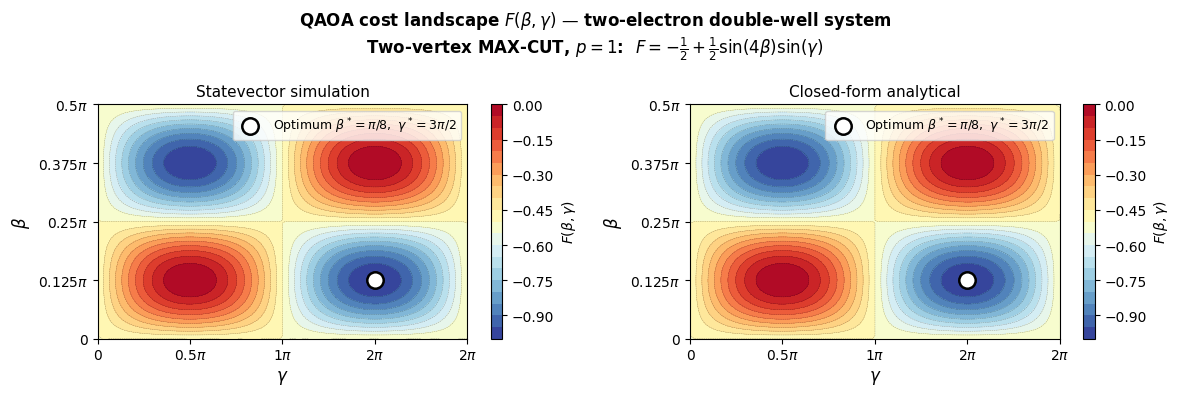

Figure saved to ../plots/qaoa_landscape.png


In [43]:
beta_opt, gamma_opt = np.pi/8, 3*np.pi/2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    r'QAOA cost landscape $F(\beta,\gamma)$ — two-electron double-well system' '\n'
    r'Two-vertex MAX-CUT, $p=1$:  $F = -\frac{1}{2} + \frac{1}{2}\sin(4\beta)\sin(\gamma)$',
    fontsize=12, fontweight='bold'
)

levels = np.linspace(-1, 0, 21)
for ax, data, title in zip(
    axes,
    [F_num, F_ana],
    ['Statevector simulation', 'Closed-form analytical']
):
    im = ax.contourf(G, B, data, levels=levels, cmap='RdYlBu_r')
    ax.contour(G, B, data, levels=levels, colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(im, ax=ax, label=r'$F(\beta,\gamma)$')
    ax.scatter(gamma_opt, beta_opt, s=140, c='white', edgecolors='black',
               linewidths=1.8, zorder=5,
               label=r'Optimum $\beta^*=\pi/8,\ \gamma^*=3\pi/2$')
    ax.set_xlabel(r'$\gamma$', fontsize=12)
    ax.set_ylabel(r'$\beta$',  fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, np.pi/2)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: rf'${v/np.pi:.1g}\pi$' if v > 0 else '0'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: rf'${v/np.pi:.3g}\pi$' if v > 0 else '0'))
    ax.xaxis.set_major_locator(MultipleLocator(np.pi/2))
    ax.yaxis.set_major_locator(MultipleLocator(np.pi/8))
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../plots/qaoa_landscape.png', dpi=140, bbox_inches='tight')
plt.show()
print('Figure saved to ../plots/qaoa_landscape.png')

### ONE-DIM SLICES THROUGH THE LANDSCAPE

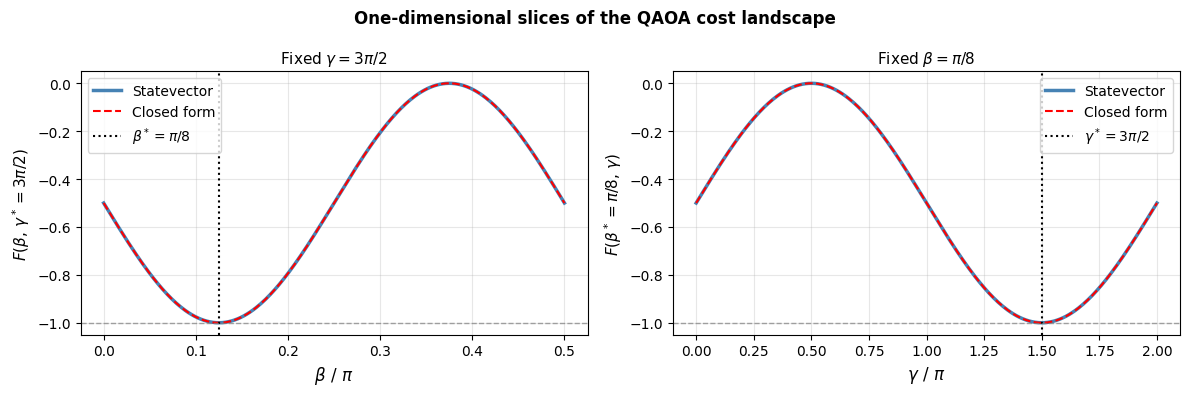

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('One-dimensional slices of the QAOA cost landscape',
             fontsize=12, fontweight='bold')

bv = np.linspace(0, np.pi/2, 300)
ax1.plot(bv/np.pi, [expected_cost(b, gamma_opt) for b in bv],
         'steelblue', lw=2.5, label='Statevector')
ax1.plot(bv/np.pi, closed_form(bv, gamma_opt),
         'r--', lw=1.5, label='Closed form')
ax1.axvline(beta_opt/np.pi, color='k', ls=':', lw=1.5,
            label=r'$\beta^* = \pi/8$')
ax1.axhline(-1, color='gray', ls='--', lw=1, alpha=0.7)
ax1.set_xlabel(r'$\beta\ /\ \pi$', fontsize=12)
ax1.set_ylabel(r'$F(\beta,\, \gamma^*{=}3\pi/2)$', fontsize=11)
ax1.set_title(r'Fixed $\gamma = 3\pi/2$', fontsize=11)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

gv = np.linspace(0, 2*np.pi, 300)
ax2.plot(gv/np.pi, [expected_cost(beta_opt, g) for g in gv],
         'steelblue', lw=2.5, label='Statevector')
ax2.plot(gv/np.pi, closed_form(beta_opt, gv),
         'r--', lw=1.5, label='Closed form')
ax2.axvline(gamma_opt/np.pi, color='k', ls=':', lw=1.5,
            label=r'$\gamma^* = 3\pi/2$')
ax2.axhline(-1, color='gray', ls='--', lw=1, alpha=0.7)
ax2.set_xlabel(r'$\gamma\ /\ \pi$', fontsize=12)
ax2.set_ylabel(r'$F(\beta^*{=}\pi/8,\, \gamma)$', fontsize=11)
ax2.set_title(r'Fixed $\beta = \pi/8$', fontsize=11)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/qaoa_slices.png', dpi=140, bbox_inches='tight')
plt.show()

### Classical optim

In [45]:
def objective(params):
    return expected_cost(params[0], params[1])

print('COBYLA optimisation (20 random restarts) ...')

best_cobyla = None

for _ in range(20):
    b0 = np.random.uniform(0, np.pi/2)
    g0 = np.random.uniform(0, 2*np.pi)
    res = minimize(objective, [b0, g0], method='COBYLA', options={'maxiter': 1000, 'rhobeg':0.3})

    if best_cobyla is None or res.fun < best_cobyla.fun:
        best_cobyla = res
    
b_co, g_co = best_cobyla.x
print(f'  beta*  = {b_co:.5f}  ({b_co/np.pi:.4f} pi)')
print(f'  gamma* = {g_co:.5f}  ({g_co/np.pi:.4f} pi)')
print(f'  F*     = {best_cobyla.fun:.6f}')
print('\nBFGS optimisation (20 random restarts) ...')

best_bfgs = None
for _ in range(20):
    b0  = np.random.uniform(0, np.pi/2)
    g0  = np.random.uniform(0, 2*np.pi)
    res = minimize(objective, [b0, g0], method='BFGS',
                   options={'maxiter': 500})
    if best_bfgs is None or res.fun < best_bfgs.fun:
        best_bfgs = res

b_bf, g_bf = best_bfgs.x
print(f'  beta*  = {b_bf:.5f}  ({b_bf/np.pi:.4f} pi)')
print(f'  gamma* = {g_bf:.5f}  ({g_bf/np.pi:.4f} pi)')
print(f'  F*     = {best_bfgs.fun:.6f}')


b_opt = np.pi/8;  g_opt = 3*np.pi/2
F_opt = closed_form(b_opt, g_opt)
print(f'\nAnalytical:  beta* = pi/8 = {b_opt:.5f},  gamma* = 3*pi/2 = {g_opt:.5f},  F* = {F_opt:.6f}')
print(f'\n|F_COBYLA - F_opt| = {abs(best_cobyla.fun - F_opt):.2e}')
print(f'|F_BFGS   - F_opt| = {abs(best_bfgs.fun   - F_opt):.2e}')


COBYLA optimisation (20 random restarts) ...
  beta*  = 0.39273  (0.1250 pi)
  gamma* = 4.71232  (1.5000 pi)
  F*     = -1.000000

BFGS optimisation (20 random restarts) ...
  beta*  = 0.39270  (0.1250 pi)
  gamma* = 4.71239  (1.5000 pi)
  F*     = -1.000000

Analytical:  beta* = pi/8 = 0.39270,  gamma* = 3*pi/2 = 4.71239,  F* = -1.000000

|F_COBYLA - F_opt| = 4.85e-09
|F_BFGS   - F_opt| = 0.00e+00


### Optimal state and measurement probabilities


Optimal state probabilities:
  P(|00>) = P(|up-up>) = 0.0000
  P(|01>) = P(|up-dn>) = 0.5000  <-- MAX-CUT solution
  P(|10>) = P(|dn-up>) = 0.5000  <-- MAX-CUT solution
  P(|11>) = P(|dn-dn>) = 0.0000

Expected cost F* = -1.0000
P(finding a solution) = P(|01>) + P(|10>) = 1.0000

|<T0|psi*>|^2 = 1.000000  (1.0 means psi* = |T0>)


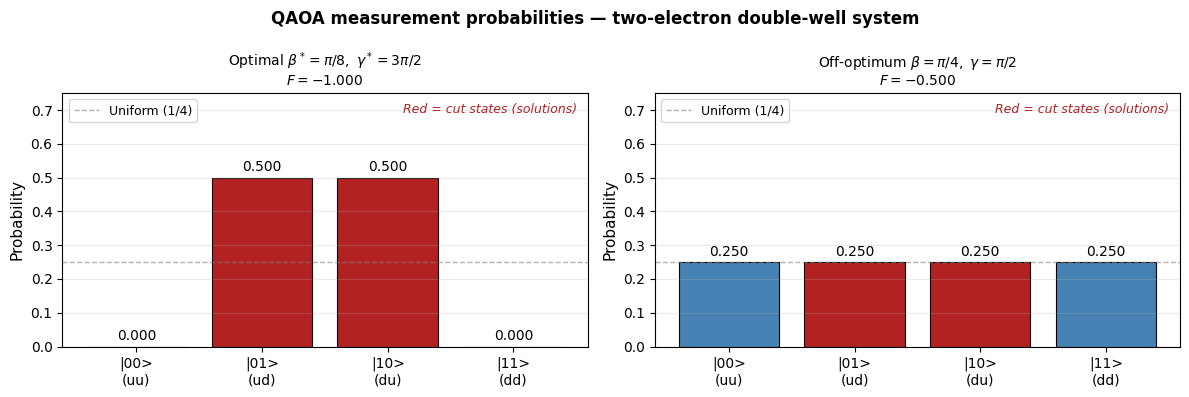

In [46]:
psi_opt = qaoa_state(b_opt, g_opt)
probs = np.abs(psi_opt)**2

print('\nOptimal state probabilities:')

for k, (lbl, sp) in enumerate(zip(['|00>','|01>','|10>','|11>'],
                                   ['|up-up>','|up-dn>','|dn-up>','|dn-dn>'])):
    sol = '  <-- MAX-CUT solution' if np.diag(H_C).real[k] < 0 else ''
    print(f'  P({lbl}) = P({sp}) = {probs[k]:.4f}{sol}')

print(f'\nExpected cost F* = {(psi_opt.conj() @ H_C @ psi_opt).real:.4f}')
print(f'P(finding a solution) = P(|01>) + P(|10>) = {probs[1]+probs[2]:.4f}')

T0 = np.array([0, 1, 1, 0], dtype=complex) / np.sqrt(2)
print(f'\n|<T0|psi*>|^2 = {abs(np.vdot(T0, psi_opt))**2:.6f}  (1.0 means psi* = |T0>)')

colours = ['steelblue', 'firebrick', 'firebrick', 'steelblue']
bar_labels = ['|00>\n(uu)', '|01>\n(ud)', '|10>\n(du)', '|11>\n(dd)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('QAOA measurement probabilities — two-electron double-well system',
             fontsize=12, fontweight='bold')

for ax, (b, g), subtitle in zip(
    axes,
    [(b_opt, g_opt), (np.pi/4, np.pi/2)],
    [r'Optimal $\beta^*=\pi/8,\ \gamma^*=3\pi/2$',
     r'Off-optimum $\beta=\pi/4,\ \gamma=\pi/2$']
):
    pv = np.abs(qaoa_state(b, g))**2
    ax.bar(bar_labels, pv, color=colours, edgecolor='black', linewidth=0.8)
    for k_b, p_b in enumerate(pv):
        ax.text(k_b, p_b+0.01, f'{p_b:.3f}', ha='center', va='bottom', fontsize=10)
    ax.axhline(0.25, color='gray', ls='--', lw=1, alpha=0.6, label='Uniform (1/4)')
    ax.set_ylim(0, 0.75)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(subtitle + f'\n$F = {expected_cost(b,g):.3f}$', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    ax.text(0.98, 0.96, 'Red = cut states (solutions)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='firebrick', style='italic')

plt.tight_layout()
plt.savefig('qaoa_probabilities.png', dpi=140, bbox_inches='tight')
plt.show()